<a href="https://colab.research.google.com/github/amitpaul05/Journey-to-AI/blob/master/CWRU_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d brjapon/cwru-bearing-datasets



Dataset URL: https://www.kaggle.com/datasets/brjapon/cwru-bearing-datasets
License(s): CC-BY-SA-4.0
cwru-bearing-datasets.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
import os
import zipfile

# Unzip the dataset
with zipfile.ZipFile("cwru-bearing-datasets.zip", 'r') as zip_ref:
    zip_ref.extractall("cwru_data")


Files: ['raw', 'feature_time_48k_2048_load_1.csv', 'CWRU_48k_load_1_CNN_data.npz']
Loaded signal key: X123_DE_time


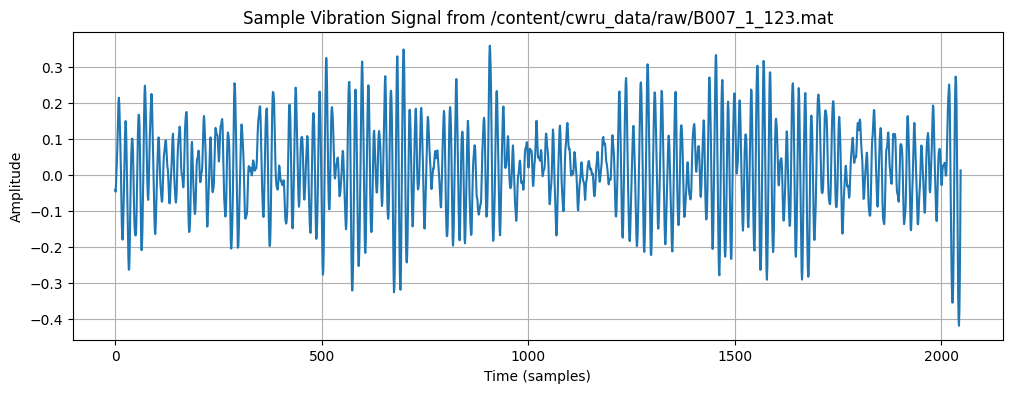

In [6]:
import scipy.io
import matplotlib.pyplot as plt
import os

# List available files
files = os.listdir('cwru_data')
print("Files:", files)

# Load a sample file
mat_path = '/content/cwru_data/raw/B007_1_123.mat'
data = scipy.io.loadmat(mat_path)

# Find the vibration signal
for key in data:
    if '_DE_time' in key:
        signal = data[key].flatten()
        print(f"Loaded signal key: {key}")
        break

# Plot the signal
plt.figure(figsize=(12, 4))
plt.plot(signal[:2048])
plt.title(f'Sample Vibration Signal from {mat_path}')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


In [7]:
import scipy.io
import matplotlib.pyplot as plt
import numpy as np

# Healthy signal
normal_file = '/content/cwru_data/raw/Time_Normal_1_098.mat'
normal_data = scipy.io.loadmat(normal_file)

# Faulty signal (example: Ball fault)
fault_file = '/content/cwru_data/raw/B007_1_123.mat'
fault_data = scipy.io.loadmat(fault_file)

# Function to extract drive-end signal from .mat file
def extract_signal(data):
    for key in data:
        if "_DE_time" in key:
            return data[key].flatten(), key
    return None, None

normal_signal, normal_key = extract_signal(normal_data)
fault_signal, fault_key = extract_signal(fault_data)

print("Normal key:", normal_key)
print("Faulty key:", fault_key)


Normal key: X098_DE_time
Faulty key: X123_DE_time


<ipython-input-8-0331b4b533fc>:18: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-8-0331b4b533fc>:18: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


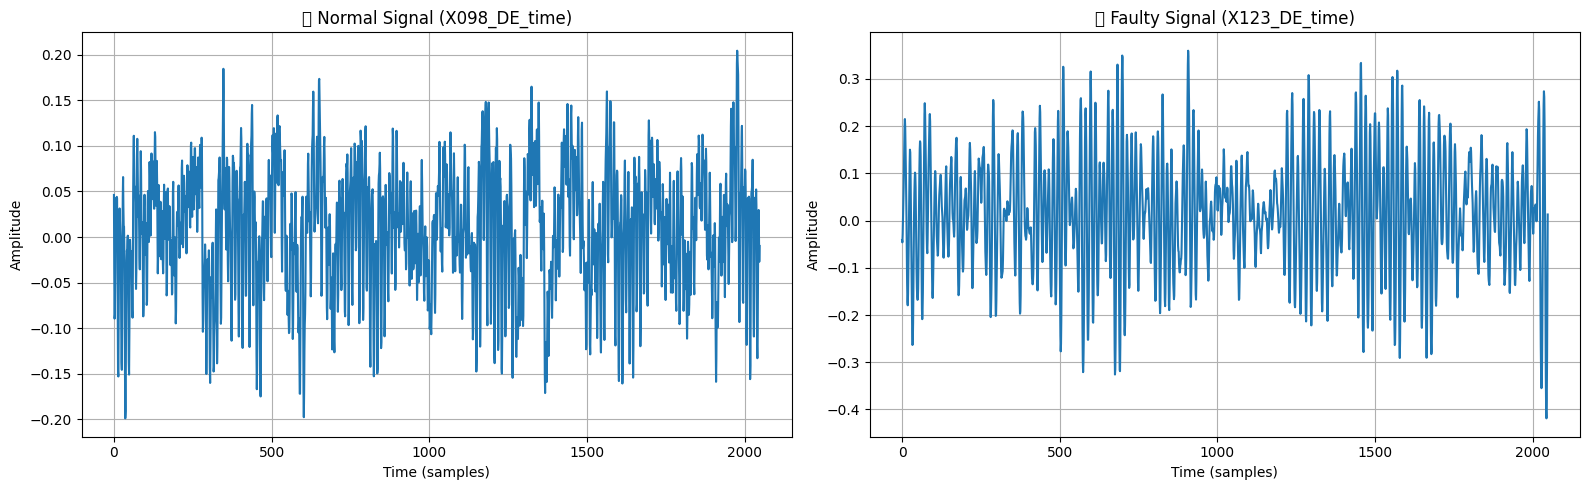

In [8]:
# Plot side-by-side comparison
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.plot(normal_signal[:2048])
plt.title(f'🟢 Normal Signal ({normal_key})')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(fault_signal[:2048])
plt.title(f'🔴 Faulty Signal ({fault_key})')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()


In [9]:
!ls cwru_data/raw/

B007_1_123.mat	IR007_1_110.mat  OR007_6_1_136.mat  Time_Normal_1_098.mat
B014_1_190.mat	IR014_1_175.mat  OR014_6_1_202.mat
B021_1_227.mat	IR021_1_214.mat  OR021_6_1_239.mat


In [10]:
import scipy.io

data = scipy.io.loadmat('cwru_data/raw/B014_1_190.mat')
print(data.keys())


dict_keys(['__header__', '__version__', '__globals__', 'X190_DE_time', 'X190_FE_time', 'X190RPM'])


(486224,)


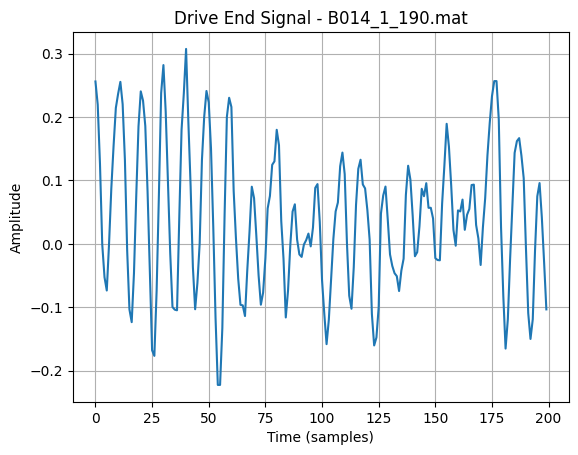

In [11]:
signal = data['X190_FE_time'].flatten()
print(signal.shape)

import matplotlib.pyplot as plt

plt.plot(signal[:200])
plt.title("Drive End Signal - B014_1_190.mat")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


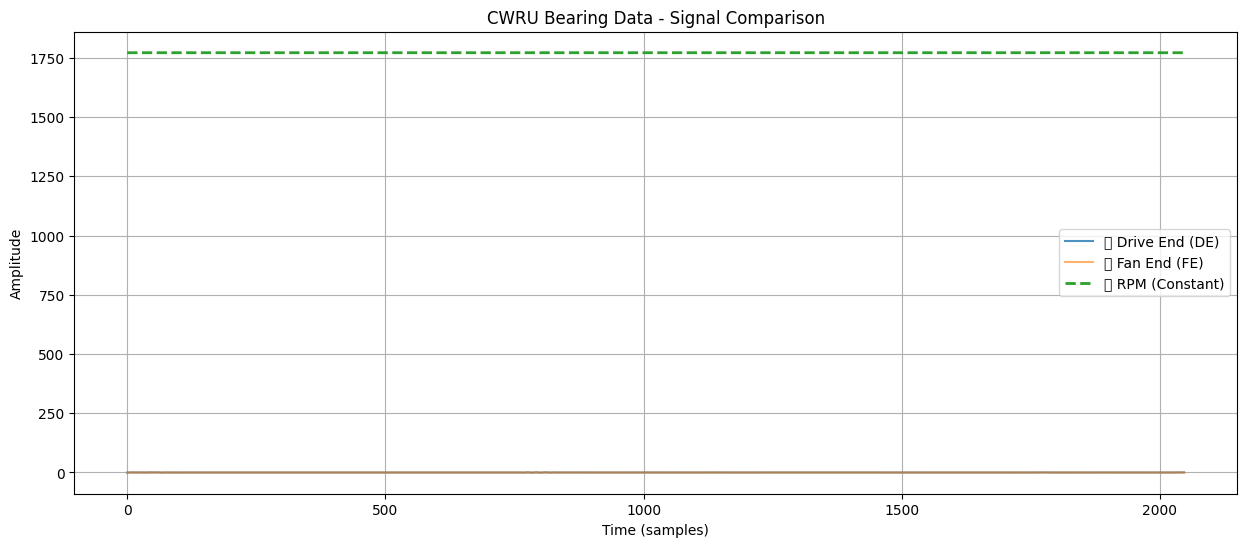

In [12]:
# Extract signals
de = data['X190_DE_time'].flatten()
fe = data['X190_FE_time'].flatten()
rpm = data['X190RPM'].flatten()

# Use a short slice for visualization
sample_len = 2048
de_slice = de[:sample_len]
fe_slice = fe[:sample_len]
rpm_slice = [rpm[0]] * sample_len  # RPM is constant

# Plotting
plt.figure(figsize=(15, 6))

plt.plot(de_slice, label='🔵 Drive End (DE)', alpha=0.8)
plt.plot(fe_slice, label='🟢 Fan End (FE)', alpha=0.6)
plt.plot(rpm_slice, label='🔴 RPM (Constant)', linestyle='--', linewidth=2)

plt.title("CWRU Bearing Data - Signal Comparison")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

<ipython-input-13-790efe02d008>:27: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


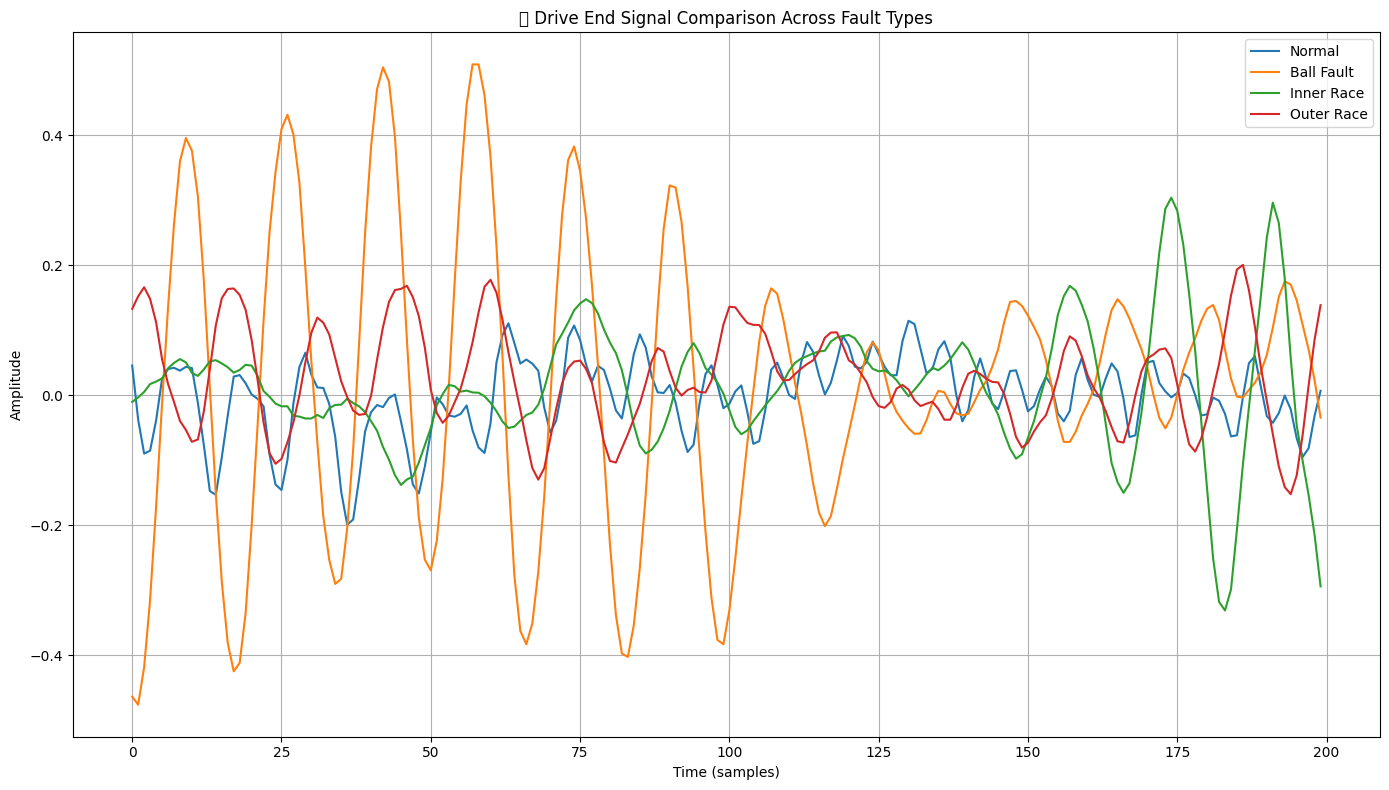

In [13]:
import scipy.io
import matplotlib.pyplot as plt

# File paths and keys
files = {
    "Normal":       ("cwru_data/raw/Time_Normal_1_098.mat", "X098_DE_time"),
    "Ball Fault":   ("cwru_data/raw/B014_1_190.mat",        "X190_DE_time"),
    "Inner Race":   ("cwru_data/raw/IR014_1_175.mat",       "X175_DE_time"),
    "Outer Race":   ("cwru_data/raw/OR014_6_1_202.mat",     "X202_DE_time"),
}

# Plot setup
plt.figure(figsize=(14, 8))
sample_len = 200

# Plot each
for label, (file_path, key) in files.items():
    data = scipy.io.loadmat(file_path)
    signal = data[key].flatten()
    plt.plot(signal[:sample_len], label=label)

plt.title("🔧 Drive End Signal Comparison Across Fault Types")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# FFT comparison

<ipython-input-14-90fb6a0c5258>:39: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


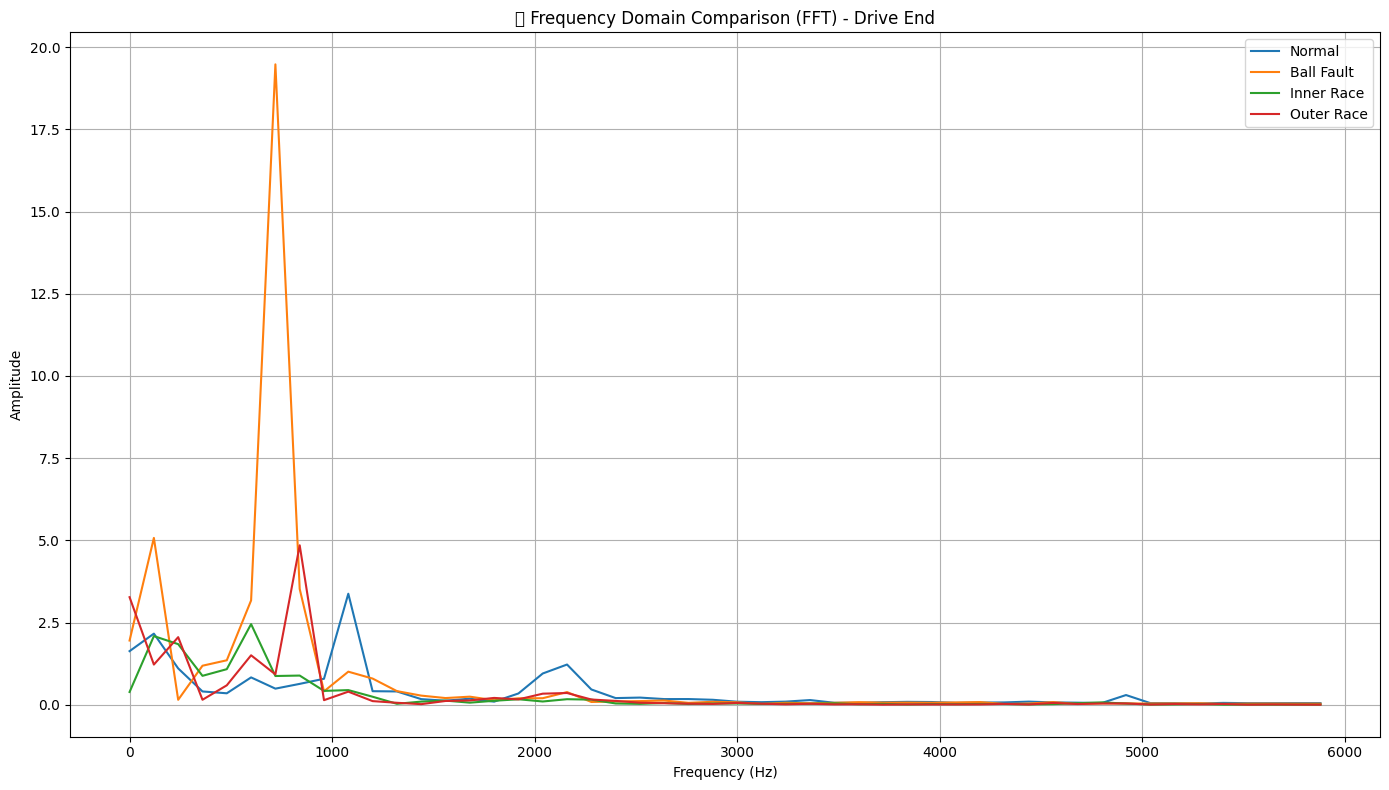

In [14]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

# File paths and keys
files = {
    "Normal":       ("cwru_data/raw/Time_Normal_1_098.mat", "X098_DE_time"),
    "Ball Fault":   ("cwru_data/raw/B014_1_190.mat",        "X190_DE_time"),
    "Inner Race":   ("cwru_data/raw/IR014_1_175.mat",       "X175_DE_time"),
    "Outer Race":   ("cwru_data/raw/OR014_6_1_202.mat",     "X202_DE_time"),
}

sample_len = 100  # Enough for resolution, but fast to compute
fs = 12000         # Sampling frequency (can also be 48kHz in other files)

plt.figure(figsize=(14, 8))

# Process each signal
for label, (file_path, key) in files.items():
    data = scipy.io.loadmat(file_path)
    signal = data[key].flatten()[:sample_len]

    # Apply FFT
    fft_vals = np.fft.fft(signal)
    fft_freq = np.fft.fftfreq(sample_len, 1/fs)

    # Take only the positive frequencies
    fft_magnitude = np.abs(fft_vals)[:sample_len // 2]
    fft_freq = fft_freq[:sample_len // 2]

    # Plot
    plt.plot(fft_freq, fft_magnitude, label=label)

plt.title("📈 Frequency Domain Comparison (FFT) - Drive End")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Load and Label CWRU Signals

In [15]:
import os
import scipy.io
import numpy as np

# Path to your dataset folder
DATA_DIR = "cwru_data/raw/"


# Better labeling logic using substrings
def get_label_from_filename(filename):
    if "B0" in filename:
        return "ball_fault"
    elif "IR0" in filename:
        return "inner_race_fault"
    elif "OR0" in filename:
        return "outer_race_fault"
    elif "Normal" in filename:
        return "normal"
    else:
        return "unknown"

def extract_key(mat_data):
    """Find Drive End signal key."""
    for key in mat_data.keys():
        if "_DE_time" in key:
            return key
    return None

def load_cwru_signals(data_dir=DATA_DIR):
    data = []

    for filename in os.listdir(data_dir):
        if filename.endswith(".mat"):
            label = get_label_from_filename(filename)
            file_path = os.path.join(data_dir, filename)
            mat_data = scipy.io.loadmat(file_path)

            signal_key = extract_key(mat_data)
            if signal_key:
                signal = mat_data[signal_key].flatten()
                data.append((signal, label))
            else:
                print(f"⚠️ Skipped {filename} (DE signal not found)")

    return data

# Test it
labeled_signals = load_cwru_signals()

# Preview
for i, (signal, label) in enumerate(labeled_signals[:5]):
    print(f"[{i}] Label: {label}, Length: {len(signal)}")


[0] Label: inner_race_fault, Length: 485063
[1] Label: inner_race_fault, Length: 486224
[2] Label: ball_fault, Length: 486804
[3] Label: inner_race_fault, Length: 489125
[4] Label: normal, Length: 483903


# Applying CNN

Slice Signals into Fixed-Length Windows

In [16]:
def create_windows(signal, label, window_size=2048, stride=2048):
    windows = []
    for start in range(0, len(signal) - window_size + 1, stride):
        window = signal[start:start+window_size]
        windows.append((window, label))
    return windows


Prepare Dataset (Windowed Signals)

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

def prepare_dataset(labeled_signals, window_size=2048):
    X = []
    y = []

    for signal, label in labeled_signals:
        # Plot the full signal before windowing
        plt.figure(figsize=(10, 3))
        plt.plot(signal)
        plt.title(f"Full Signal - Label: {label}")
        plt.xlabel("Sample Index")
        plt.ylabel("Amplitude")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        windows = create_windows(signal, label, window_size)
        for window, lbl in windows:
            X.append(window)
            y.append(lbl)

    X = np.array(X)
    y = np.array(y)

    # Encode labels to integers then one-hot
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    y_onehot = to_categorical(y_encoded)

    # Add channel dimension for CNN
    X = X[..., np.newaxis]

    return train_test_split(X, y_onehot, test_size=0.2, random_state=42), le




CNN Model( 1D )

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

def build_cnn(input_shape, num_classes):
    model = Sequential([
        Conv1D(32, 5, activation='relu', input_shape=input_shape),
        MaxPooling1D(2),
        Dropout(0.3),

        Conv1D(64, 5, activation='relu'),
        MaxPooling1D(2),
        Dropout(0.3),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


Train the Model

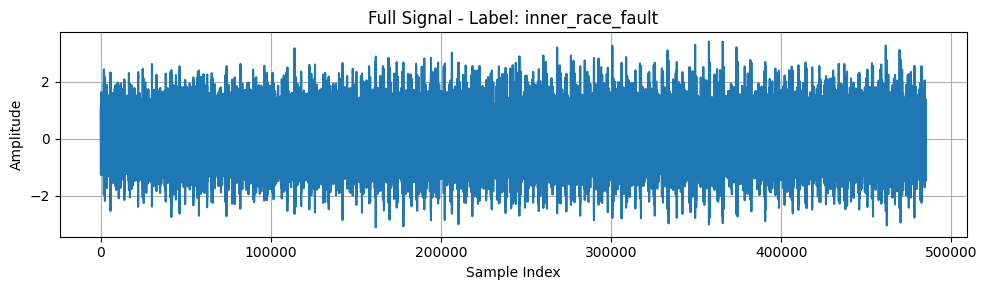

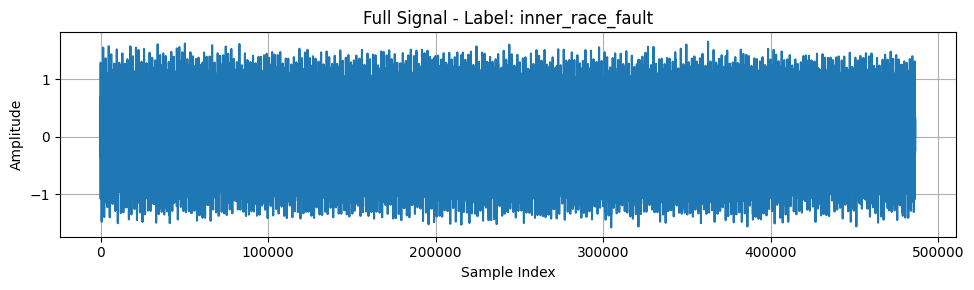

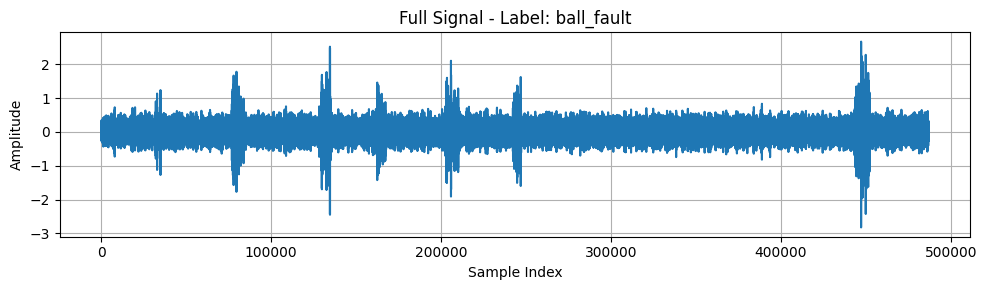

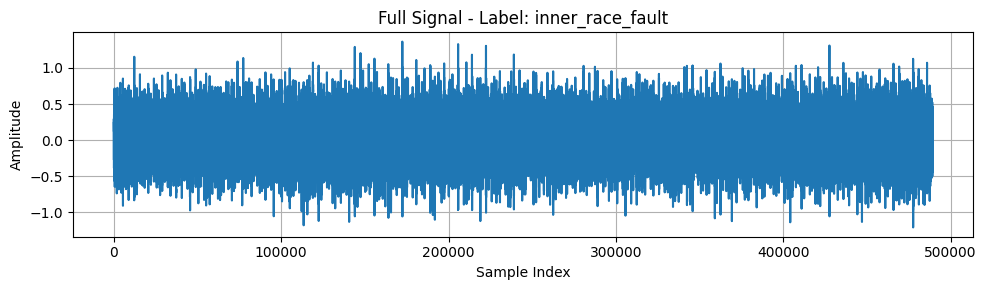

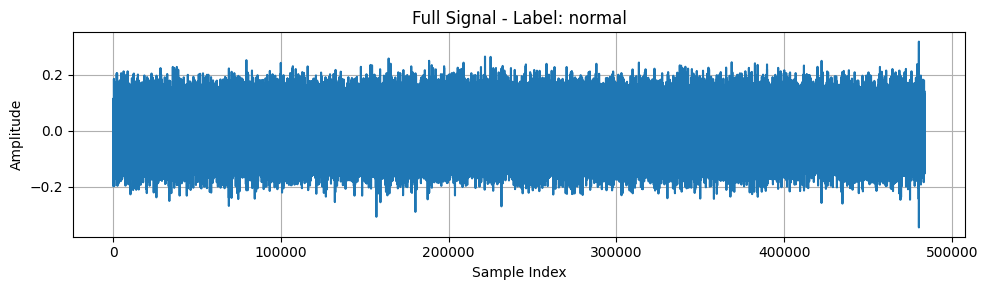

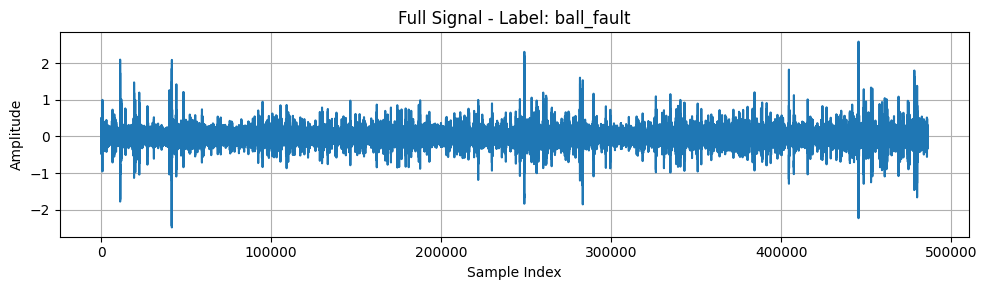

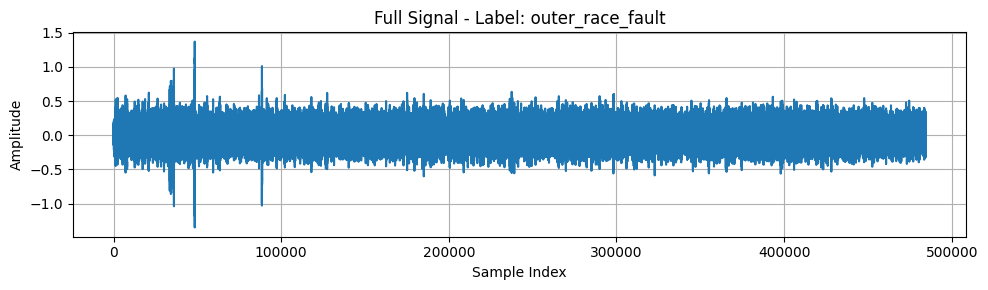

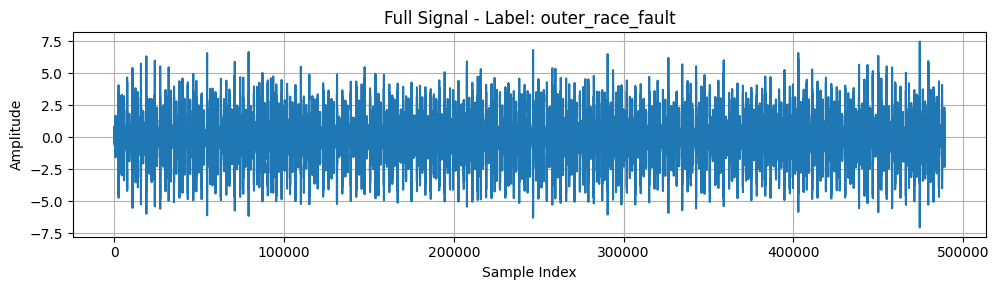

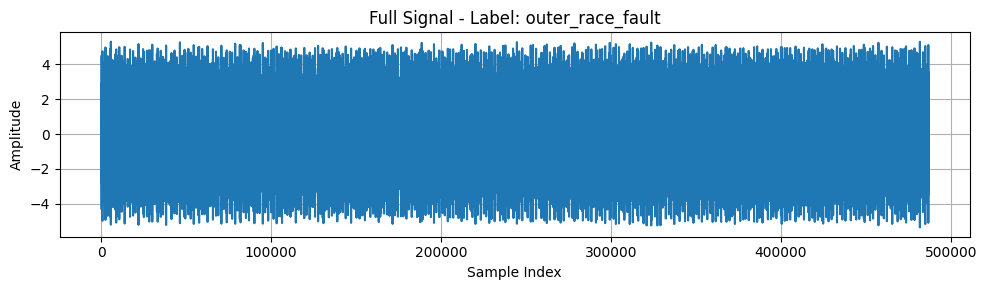

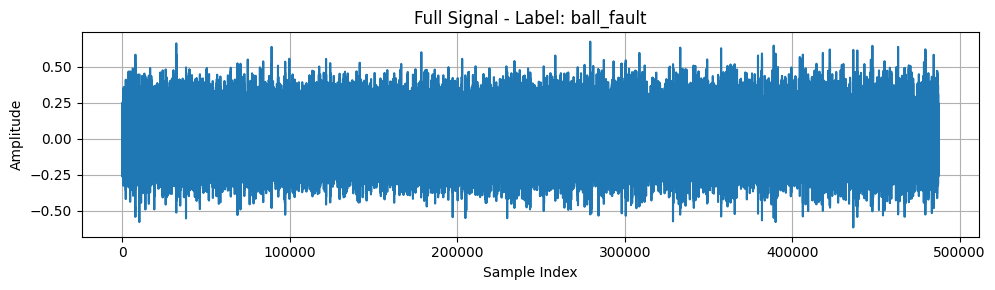

In [19]:
# Load and prepare data
(X_train, X_test, y_train, y_test), label_encoder = prepare_dataset(labeled_signals)

In [20]:
model = build_cnn(input_shape=X_train.shape[1:], num_classes=y_train.shape[1])
model.summary()

history = model.fit(X_train, y_train, epochs=10, batch_size=32,
                    validation_data=(X_test, y_test))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2044, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1022, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1022, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1018, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 509, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 509, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32576)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,169,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,180,868 (15.95 MB)

 Trainable params: 4,180,868 (15.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.3255 - loss: 1.2498 - val_accuracy: 0.7004 - val_loss: 0.8043
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7233 - loss: 0.7323 - val_accuracy: 0.8692 - val_loss: 0.4121
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8325 - loss: 0.4454 - val_accuracy: 0.8776 - val_loss: 0.3634
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8805 - loss: 0.2986 - val_accuracy: 0.9030 - val_loss: 0.2517
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8865 - loss: 0.2827 - val_accuracy: 0.9051 - val_loss: 0.2356
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8989 - loss: 0.2281 - val_accuracy: 0.9114 - val_loss: 0.2036
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9180 - loss: 0.2058 - val_accuracy: 0.9262 - val_loss: 0.2339
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9426 - loss: 0.1707 - val_accuracy: 0.8397 - 

In [21]:
y_train

array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       ...,
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.]])

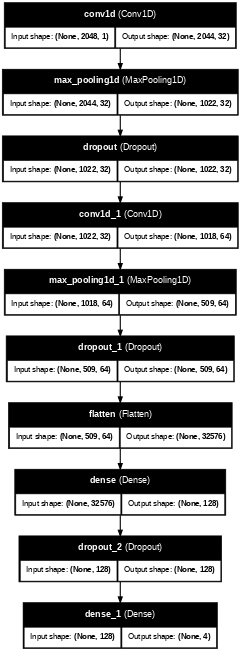

In [22]:
# model visualization
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model_plot.png',
           show_shapes=True, show_layer_names=True,
           dpi=40)


Evaluation

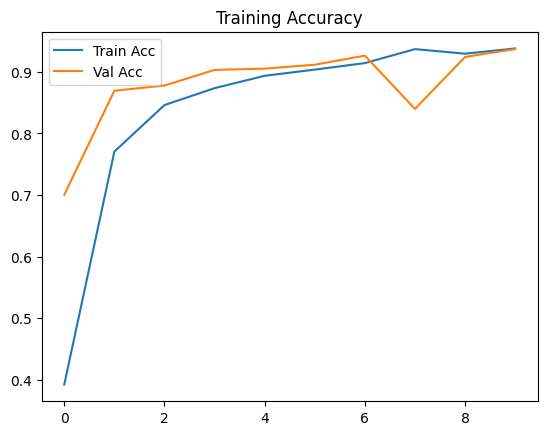

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9362 - loss: 0.1581 
Test Accuracy: 93.67%


In [23]:
import matplotlib.pyplot as plt

# Plot training history
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.legend()
plt.title("Training Accuracy")
plt.show()

# Evaluate on test set
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.2%}")


# Decoder Only Transformer

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models

def get_positional_encoding(seq_len, d_model):
    """Generate positional encoding for the transformer."""
    position = tf.range(seq_len, dtype=tf.float32)[:, tf.newaxis]
    i = tf.range(d_model, dtype=tf.float32)[tf.newaxis, :]
    angle_rates = 1 / tf.pow(10000.0, (2 * (i // 2)) / tf.cast(d_model, tf.float32))
    angle_rads = position * angle_rates

    sines = tf.sin(angle_rads[:, 0::2])
    cosines = tf.cos(angle_rads[:, 1::2])
    pos_encoding = tf.concat([sines, cosines], axis=-1)
    return tf.expand_dims(pos_encoding, axis=0)  # shape: (1, seq_len, d_model)


class TransformerBlock(layers.Layer):
    def __init__(self, head_size, num_heads, ff_dim, dropout=0.1):
        """Initialize the transformer block with multi-head attention, dropout, and feed-forward network."""
        super(TransformerBlock, self).__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size)
        self.dropout1 = layers.Dropout(dropout)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)

        # Feed-forward network (FFN) output must match the input dimension (head_size * num_heads)
        self.ffn = tf.keras.Sequential([
            layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu"),
            layers.Dropout(dropout),
            layers.Conv1D(filters=head_size, kernel_size=1)  # Match input dimension to embed_dim
        ])
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, inputs, training=False):
        """Forward pass through the transformer block."""
        attn_output = self.att(inputs, inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.norm1(inputs + attn_output)  # Residual connection

        ffn_output = self.ffn(out1, training=training)
        return self.norm2(out1 + ffn_output)  # Residual connection


def build_transformer_model(seq_len=2048, num_classes=4, embed_dim=256):
    """Build the full transformer model with input, transformer blocks, and output layers."""
    inputs = layers.Input(shape=(seq_len, 64))  # Shape: (batch_size, seq_len, input_dim)

    # Apply positional encoding and convolution to embed the input time-series signal
    x = layers.Conv1D(embed_dim, kernel_size=1)(inputs)  # Project to higher dimension
    x += get_positional_encoding(seq_len, embed_dim)  # Add positional encoding

    # Apply multiple transformer blocks
    x = TransformerBlock(head_size=embed_dim, num_heads=4, ff_dim=128)(x)
    x = TransformerBlock(head_size=embed_dim, num_heads=4, ff_dim=128)(x)

    # Global average pooling and output layers
    x = layers.GlobalAveragePooling1D()(x)  # Pool across the time dimension
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    # Return the Keras model
    return tf.keras.Model(inputs, outputs)



In [25]:
model = build_transformer_model(seq_len=2048, num_classes=4)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2048, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2048, 256)      │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 2048, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 2048, 256)      │     1,118,848 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 2048, 256)      │     1,118,848 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,271,044 (8.66 MB)

 Trainable params: 2,271,044 (8.66 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

def prepare_dataset(labeled_signals, window_size=2048):
    X = []
    y = []

    for signal, label in labeled_signals:
        # Plot the full signal before windowing
        plt.figure(figsize=(10, 3))
        plt.plot(signal)
        plt.title(f"Full Signal - Label: {label}")
        plt.xlabel("Sample Index")
        plt.ylabel("Amplitude")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        windows = create_windows(signal, label, window_size)
        for window, lbl in windows:
            X.append(window)
            y.append(lbl)

    X = np.array(X)
    y = np.array(y)

    # Encode labels to integers then one-hot
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    y_onehot = to_categorical(y_encoded)

    # Add channel dimension for CNN and reshape to (None, 2048, 64)
    X = X[..., np.newaxis]  # Shape will be (None, 2048, 1)

    # If you need 64 features, repeat the single feature (1) 64 times
    X = np.repeat(X, 64, axis=-1)  # Now X will have shape (None, 2048, 64)

    return train_test_split(X, y_onehot, test_size=0.2, random_state=42), le


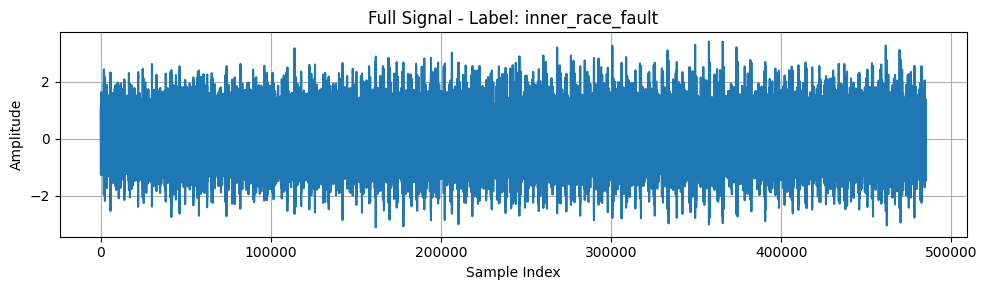

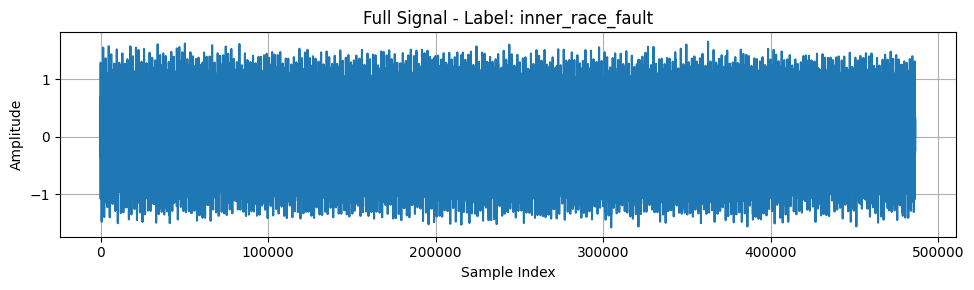

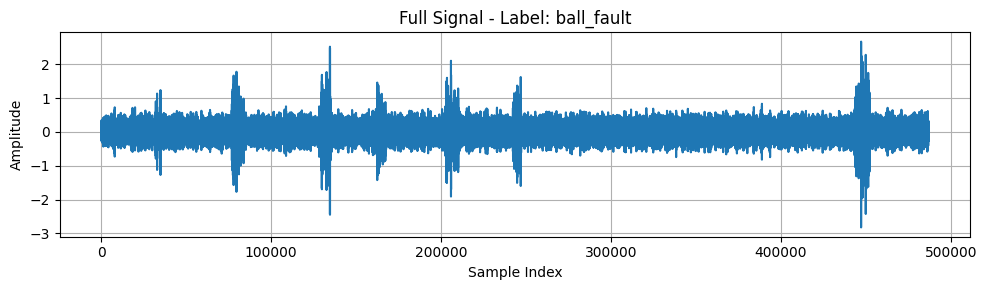

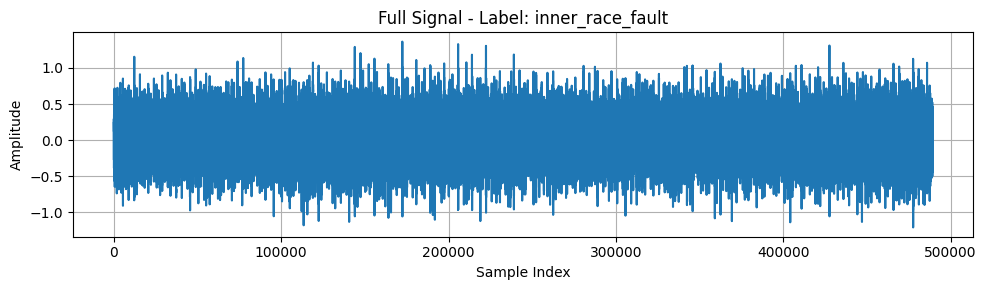

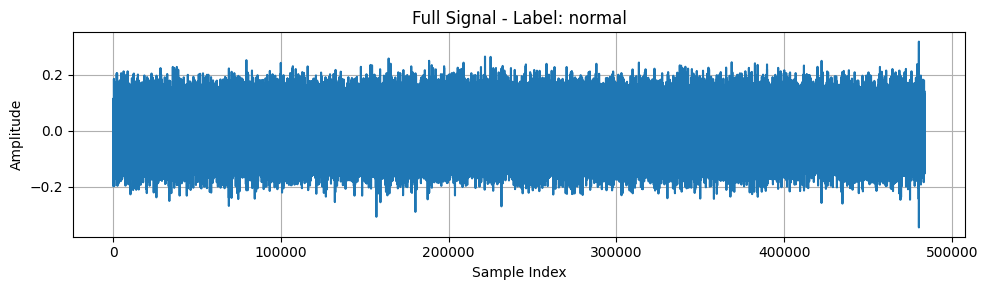

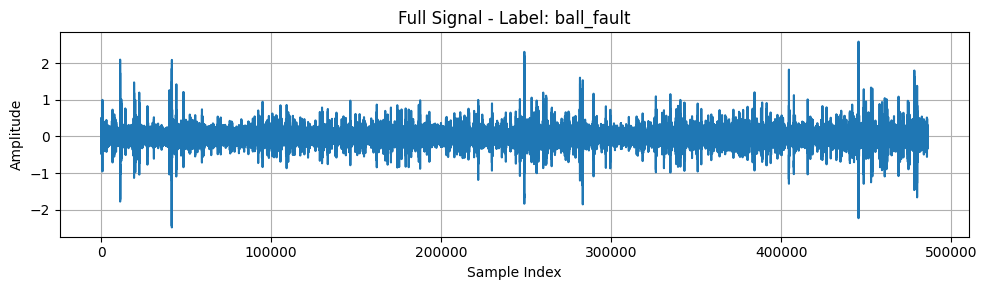

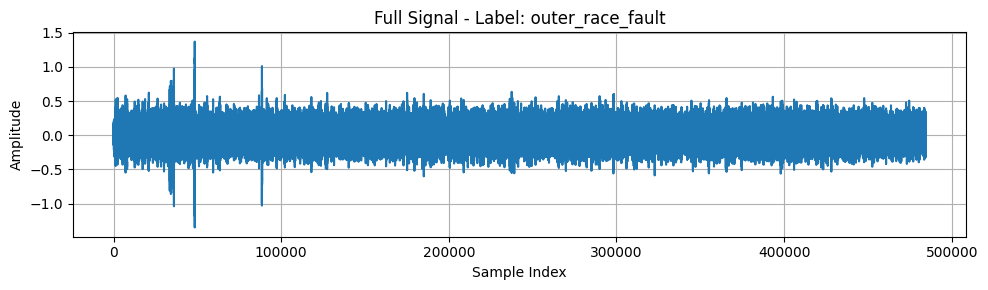

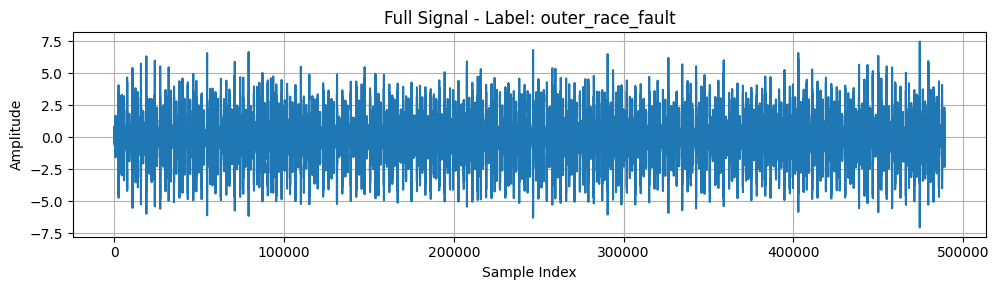

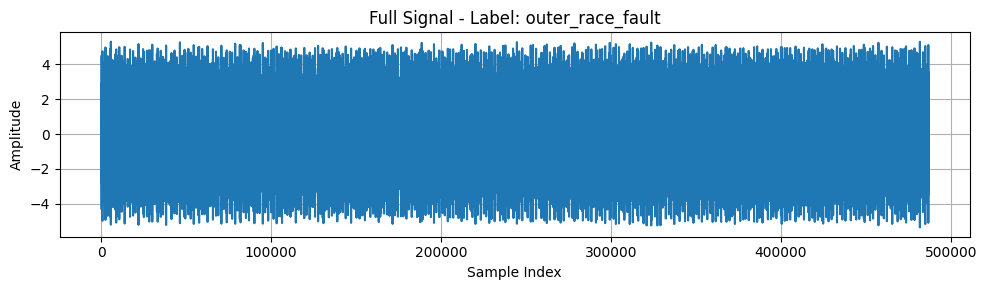

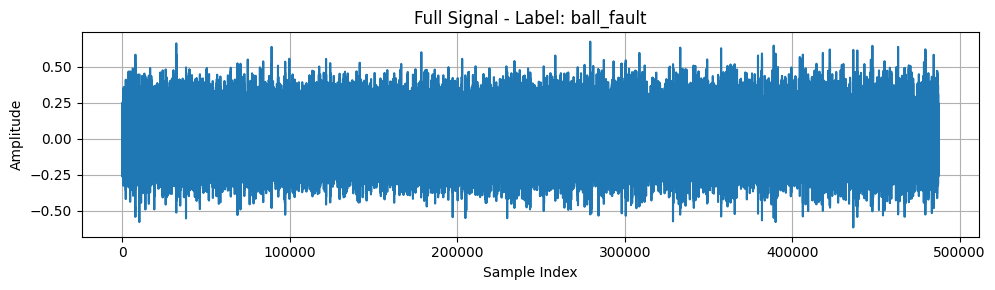

Epoch 1/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.4621 - loss: 1.2408 - val_accuracy: 0.7300 - val_loss: 0.5615
Epoch 2/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.7370 - loss: 0.6164 - val_accuracy: 0.8143 - val_loss: 0.4445
Epoch 3/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.7754 - loss: 0.5304 - val_accuracy: 0.8460 - val_loss: 0.3734
Epoch 4/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.7761 - loss: 0.5756 - val_accuracy: 0.8354 - val_loss: 0.4361
Epoch 5/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.7633 - loss: 0.5643 - val_accuracy: 0.8333 - val_loss: 0.4315
Epoch 6/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.7892 - loss: 0.4733 - val_accuracy: 0.8101 - val_loss: 0.4719
Epoch 7/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.7852 - loss: 0.4757 - val_accuracy: 0.8249 - val_loss: 0.4290
Epoch 8/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.7731 - loss: 0.5419 - val_accuracy: 0.8291 - va

In [27]:
model = build_transformer_model(seq_len=2048, num_classes=4)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

(X_train, X_test, y_train, y_test), label_encoder = prepare_dataset(labeled_signals)

model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=15, batch_size=32)

In [28]:
# Evaluate on test set
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.2%}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 418ms/step - accuracy: 0.7839 - loss: 0.6029
Test Accuracy: 79.11%
